# Atividade 06 — Classificação: Treino/Teste e CV(5)

**Script R equivalente:** [`../scriptsR/06-regressao-logistica-treino-teste.R`](../scriptsR/06-regressao-logistica-treino-teste.R)

**Explicação detalhada (consolidado):** [consolidado/06-regressao-logistica-treino-teste.md](https://github.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/blob/main/consolidado/06-regressao-logistica-treino-teste.md)

**Propósito deste notebook:** permitir a execução desta atividade no Google Colab (runtime R), exibindo todas as saídas e gráficos inline. Diferente do script `.R`, este notebook **não grava arquivos** — não salva `.png` nem relatórios `.md`.

**Alvo:** `mortalidade_alta` = 1 se `mortalidade_60_69` > mediana do TREINO.

**Como rodar no Colab:** `Runtime` → `Change runtime type` → selecionar **R** → `Run all`.


In [5]:
# =============================================================
# SETUP — Atividade 06
# =============================================================
# No Google Colab: Runtime > Change runtime type > R
# Esta atividade nao requer pacotes externos.

options(repr.plot.width = 8, repr.plot.height = 7)

cat("[INFO] Setup concluido.\n")

[INFO] Setup concluido.


In [6]:
# =============================================================
# DADOS — Atividade 06
# =============================================================
arquivo_local <- file.path("..", "bancoDeDados", "df_ipdm_baixada_por_municipio.csv")
url_github    <- "https://raw.githubusercontent.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/main/estrutura/bancoDeDados/df_ipdm_baixada_por_municipio.csv"
origem_dados <- if (file.exists(arquivo_local)) arquivo_local else url_github
if (file.exists(arquivo_local)) cat("[INFO] Carregando banco LOCAL.\n") else cat("[INFO] Carregando do GitHub.\n")

dados_brutos <- read.csv(origem_dados, sep = ";", dec = ",", fileEncoding = "latin1",
                         check.names = FALSE, stringsAsFactors = FALSE)

dados <- data.frame(
  escolaridade      = as.numeric(dados_brutos[[6]]),
  mortalidade_60_69 = as.numeric(dados_brutos[[8]]),
  distorcao_em      = as.numeric(dados_brutos[[9]])
)

metricas <- function(y, yh) {
  tab <- table(real = factor(y, c(0,1)), prev = factor(yh, c(0,1)))
  acc <- sum(diag(tab))/sum(tab)
  sens <- if(sum(tab["1",])>0) tab["1","1"]/sum(tab["1",]) else NA
  esp  <- if(sum(tab["0",])>0) tab["0","0"]/sum(tab["0",]) else NA
  list(tab=tab, acc=acc, sens=sens, esp=esp)
}
auc_fun <- function(p, y) if (length(unique(y)) < 2) 0.5 else mean(outer(p[y==1], p[y==0], ">"))

cat("[INFO] Dados carregados:", nrow(dados), "linhas.\n")

[INFO] Carregando banco LOCAL.
[INFO] Dados carregados: 54 linhas.


In [7]:
# =============================================================
# ANALISE — Atividade 06
# =============================================================
set.seed(1); n <- nrow(dados)
idx <- sample(seq_len(n), floor(0.7*n))
treino <- dados[idx, ]; teste <- dados[-idx, ]

mediana_treino <- median(treino$mortalidade_60_69)
treino$y <- as.integer(treino$mortalidade_60_69 > mediana_treino)
teste$y  <- as.integer(teste$mortalidade_60_69  > mediana_treino)

cat("\n================ BINARIZACAO ================\n")
cat("Mediana (treino):", round(mediana_treino, 4), "\n")
cat("Prop. classe 1 treino:", round(mean(treino$y), 3), "\n")
cat("Prop. classe 1 teste: ", round(mean(teste$y), 3), "\n")

m_s <- glm(y ~ escolaridade,               data = treino, family = binomial)
m_m <- glm(y ~ escolaridade + distorcao_em, data = treino, family = binomial)

cat("\n--- A: simples ---\n"); print(round(coef(summary(m_s)), 4))
cat("--- B: multiplo ---\n"); print(round(coef(summary(m_m)), 4))

ps <- predict(m_s, newdata = teste, type = "response")
pm <- predict(m_m, newdata = teste, type = "response")
ys <- as.integer(ps > 0.5); ym <- as.integer(pm > 0.5)

ms <- metricas(teste$y, ys); mm <- metricas(teste$y, ym)
auc_s <- auc_fun(ps, teste$y); auc_m <- auc_fun(pm, teste$y)

cat("\n================ TESTE (limiar 0.5) ================\n")
cat("--- A ---\n"); print(ms$tab)
cat("Acc:", round(ms$acc, 4), "| Sens:", round(ms$sens, 4),
    "| Esp:", round(ms$esp, 4), "| AUC:", round(auc_s, 4), "\n")
cat("--- B ---\n"); print(mm$tab)
cat("Acc:", round(mm$acc, 4), "| Sens:", round(mm$sens, 4),
    "| Esp:", round(mm$esp, 4), "| AUC:", round(auc_m, 4), "\n")

cat("\nMatrizes nos limiares 0.3/0.5/0.7:\n")
for (L in c(0.3, 0.5, 0.7)) {
  cat("\n--- limiar", L, "---\n")
  cat("A:\n"); print(table(real = teste$y, previsto = as.integer(ps > L)))
  cat("B:\n"); print(table(real = teste$y, previsto = as.integer(pm > L)))
}

# CV(5)
k <- 5; set.seed(1); dobra <- sample(rep(1:k, length = n))
acc_s <- numeric(k); acc_m <- numeric(k); acc_b <- numeric(k)
auc_s_cv <- numeric(k); auc_m_cv <- numeric(k)
for (j in 1:k) {
  tr <- dados[dobra != j, ]; te <- dados[dobra == j, ]
  med_j <- median(tr$mortalidade_60_69)
  tr$y <- as.integer(tr$mortalidade_60_69 > med_j)
  te$y <- as.integer(te$mortalidade_60_69 > med_j)
  m1 <- glm(y ~ escolaridade,               data = tr, family = binomial)
  m2 <- glm(y ~ escolaridade + distorcao_em, data = tr, family = binomial)
  p1 <- predict(m1, newdata = te, type = "response")
  p2 <- predict(m2, newdata = te, type = "response")
  acc_s[j] <- mean((p1 > 0.5) == te$y); acc_m[j] <- mean((p2 > 0.5) == te$y)
  maj <- as.integer(mean(tr$y) >= 0.5); acc_b[j] <- mean(maj == te$y)
  auc_s_cv[j] <- auc_fun(p1, te$y); auc_m_cv[j] <- auc_fun(p2, te$y)
}

cat("\n================ CV(5) ================\n")
print(data.frame(
  Candidato = c("Baseline","A: simples","B: multiplo"),
  Acc_pct = round(100*c(mean(acc_b), mean(acc_s), mean(acc_m)), 2),
  AUC = round(c(NA, mean(auc_s_cv), mean(auc_m_cv)), 4)
))
cat("Dobras A venceu (AUC):", sum(auc_s_cv > auc_m_cv),
    "| B venceu:", sum(auc_m_cv > auc_s_cv), "\n")

cat("\nVencedor (CV): ", if (mean(auc_s_cv) >= mean(auc_m_cv)) "A: simples" else "B: multiplo", "\n")


================ BINARIZACAO ================
Mediana (treino): 19.5337 
Prop. classe 1 treino: 0.486 
Prop. classe 1 teste:  0.471 

--- A: simples ---
             Estimate Std. Error z value Pr(>|z|)
(Intercept)    1.0216     2.5883  0.3947   0.6931
escolaridade  -2.2021     5.2559 -0.4190   0.6752
--- B: multiplo ---
             Estimate Std. Error z value Pr(>|z|)
(Intercept)   -4.2198     4.2610 -0.9903   0.3220
escolaridade   2.3661     6.0521  0.3909   0.6958
distorcao_em   0.1788     0.1180  1.5149   0.1298

================ TESTE (limiar 0.5) ================
--- A ---
    prev
real 0 1
   0 4 5
   1 8 0
Acc: 0.2353 | Sens: 0 | Esp: 0.4444 | AUC: 0.2639 
--- B ---
    prev
real 0 1
   0 7 2
   1 6 2
Acc: 0.5294 | Sens: 0.25 | Esp: 0.7778 | AUC: 0.5556 

Matrizes nos limiares 0.3/0.5/0.7:

--- limiar 0.3 ---
A:
    previsto
real 1
   0 9
   1 8
B:
    previsto
real 0 1
   0 2 7
   1 1 7

--- limiar 0.5 ---
A:
    previsto
real 0 1
   0 4 5
   1 8 0
B:
    previsto
real 0 1
 

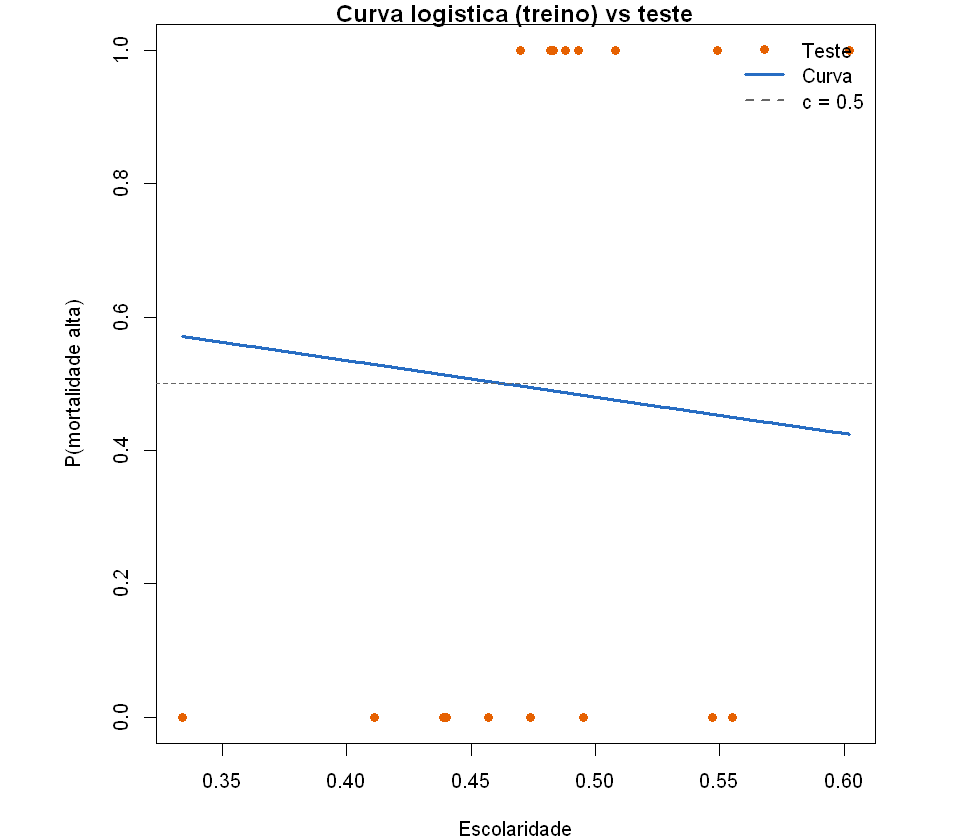

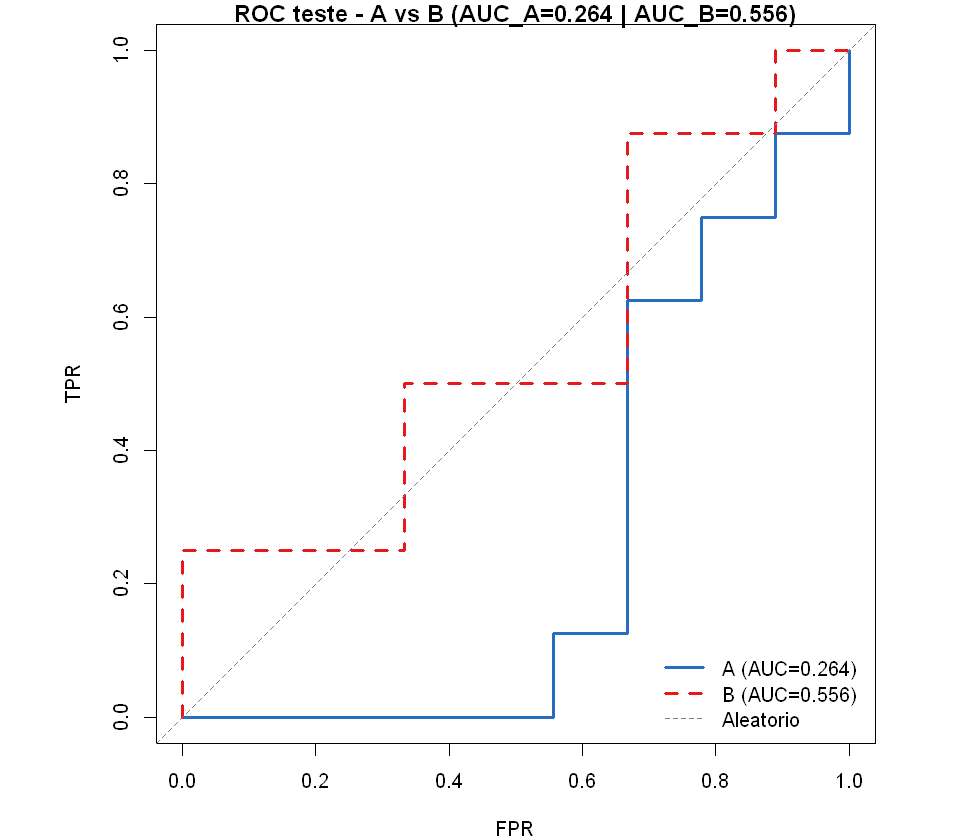

In [8]:
# =============================================================
# GRAFICOS — Atividade 06
# =============================================================
cazul <- "#276DC3"; claranja <- "#E66101"; cred <- "#E41A1C"

# Grafico 1 — curva logistica (treino) vs teste
par(mar = c(4,4,1,1), pty = "s")
grade <- seq(min(dados$escolaridade), max(dados$escolaridade), length.out = 300)
pred_g <- predict(m_s, newdata = data.frame(escolaridade = grade), type = "response")
plot(teste$escolaridade, teste$y, pch = 19, col = claranja,
     xlab = "Escolaridade", ylab = "P(mortalidade alta)",
     main = "Curva logistica (treino) vs teste")
lines(grade, pred_g, col = cazul, lwd = 3); abline(h = 0.5, lty = 2, col = "gray40")
legend("topright", c("Teste","Curva","c = 0.5"),
       col = c(claranja,cazul,"gray40"), pch = c(19,NA,NA),
       lwd = c(NA,3,2), lty = c(NA,1,2), bty = "n")

# Grafico 2 — ROC (A vs B)
roc_xy <- function(p, y) {
  o <- order(p, decreasing = TRUE)
  list(fpr = c(0, cumsum(1 - y[o])/sum(1-y)), tpr = c(0, cumsum(y[o])/sum(y)))
}
rs <- roc_xy(ps, teste$y); rm_ <- roc_xy(pm, teste$y)

par(mar = c(4,4,1,1), pty = "s")
plot(rs$fpr, rs$tpr, type = "l", lwd = 3, col = cazul, xlim = c(0,1), ylim = c(0,1),
     xlab = "FPR", ylab = "TPR",
     main = sprintf("ROC teste - A vs B (AUC_A=%.3f | AUC_B=%.3f)", auc_s, auc_m))
lines(rm_$fpr, rm_$tpr, lwd = 3, col = cred, lty = 2)
abline(0, 1, lty = 2, col = "gray50")
legend("bottomright",
       c(sprintf("A (AUC=%.3f)", auc_s), sprintf("B (AUC=%.3f)", auc_m), "Aleatorio"),
       col = c(cazul,cred,"gray50"), lwd = c(3,3,1), lty = c(1,2,2), bty = "n")